In [1]:
#imports

import torch
import pandas as pd
import numpy as np
import sklearn

print(torch.__version__)
print(sklearn.__version__)

2.1.2
1.6.1


In [2]:
%matplotlib inline

In [3]:
train_in = pd.read_csv('data/train_in.csv', header= None).values # .values convert to numpy array
train_out = pd.read_csv('data/train_out.csv', header=None).values.squeeze() # squeeze to remove 1 dimesion
test_in = pd.read_csv('data/test_in.csv', header=None).values 
test_out = pd.read_csv('data/test_out.csv', header=None).values.squeeze()

print('train in shape: ',train_in.shape)
print('test in shape: ',test_in.shape)
print('train_out shape: ',train_out.shape)
print('test_out shape: ',test_out.shape)
print('first 10 labels: ' ,train_out[:10])
print('min/max label: ' ,train_out.min(), train_out.max())

train in shape:  (1707, 256)
test in shape:  (1000, 256)
train_out shape:  (1707,)
test_out shape:  (1000,)
first 10 labels:  [6 5 4 7 3 6 3 1 0 1]
min/max label:  0 9


In [4]:
# compute mean of numbers 0 to 9 task 1 from train

means = np.zeros((10,256))
for c in range(10): 
    means[c] = train_in[train_out ==c].mean(axis=0)

print('shape of means:' ,means.shape)
print(means[0][:10])

shape of means: (10, 256)
[-1.         -0.99752351 -0.98700313 -0.9459185  -0.84404389 -0.6049906
 -0.14162069  0.1613605   0.08225078 -0.34288715]


In [5]:
# task 3: Nearest mean classifer

array = []
train_predictions= []

for i in train_in:
    array =[]
    for j in means:
        a= np.linalg.norm(i-j)
        array.append(a)
    train_predictions.append(np.argmin(array))

train_predictions = np.array(train_predictions)

if (len(train_predictions) == len(train_in)):
    print("wow, its all good here; predictions: ", len(train_predictions), " train: ", len(train_in))
else:
    print("nah smth real wrong here; predictions: ", len(train_predictions), " train: ", len(train_in))



wow, its all good here; predictions:  1707  train:  1707


In [6]:
# evaluate on test

array = []
test_predictions= []

for i in test_in:
    array =[]
    for j in means:
        a= np.linalg.norm(i-j)
        array.append(a)
    test_predictions.append(np.argmin(array))

test_predictions = np.array(test_predictions)

if (len(test_predictions) == len(test_in)):
    print("wow, its all good here; predictions: ", len(test_predictions), " train: ", len(test_in))
else:
    print("nah smth real wrong here; predictions: ", len(test_predictions), " train: ", len(test_in))


wow, its all good here; predictions:  1000  train:  1000


In [7]:
# accuracy on training 

overall_accuracy =np.sum(train_predictions==train_out)/ len(train_out)*100
print(f"Train accuracy: {overall_accuracy:.2f}%")

for group in range(10):
    # boolean mask
    mask = (train_out == group)
    group_predictions = train_predictions[mask]
    group_targets = train_out[mask]
    correct = np.sum(group_predictions == group_targets)
    total = len(group_targets)
    percentage = correct / total * 100
    print(f"digit{group}: {percentage:.1f}%({correct}/{total})")


Train accuracy: 86.35%
digit0: 85.0%(271/319)
digit1: 100.0%(252/252)
digit2: 82.7%(167/202)
digit3: 91.6%(120/131)
digit4: 77.9%(95/122)
digit5: 76.1%(67/88)
digit6: 85.4%(129/151)
digit7: 84.3%(140/166)
digit8: 84.0%(121/144)
digit9: 84.8%(112/132)


In [8]:
# accuracy on test
print("Overall accuracy on test set(1000 images)")
overall_accuracy =np.sum(test_predictions==test_out)/ len(test_out)*100
print(f"Test accuracy: {overall_accuracy:.2f}%")

for group in range(10):
    # boolean mask
    mask = (test_out == group)
    group_predictions = test_predictions[mask]
    group_targets = test_out[mask]
    correct = np.sum(group_predictions == group_targets)
    total = len(group_targets)
    percentage = correct / total * 100
    print(f"digit{group}: {percentage:.1f}%({correct}/{total})")


Overall accuracy on test set(1000 images)
Test accuracy: 80.40%
digit0: 79.5%(178/224)
digit1: 99.2%(120/121)
digit2: 68.3%(69/101)
digit3: 77.2%(61/79)
digit4: 80.2%(69/86)
digit5: 69.1%(38/55)
digit6: 86.7%(78/90)
digit7: 78.1%(50/64)
digit8: 79.3%(73/92)
digit9: 77.3%(68/88)


In [12]:
# k- sweep
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_accs =[]
test_accs =[]

ks = list(range(1,50,2))
for i in ks:
    knn =KNeighborsClassifier(n_neighbors=i)
    knn.fit(train_in,train_out)
    tr = accuracy_score(train_out, knn.predict(train_in)) * 100
    te = accuracy_score(test_out,  knn.predict(test_in))  * 100
    train_accs.append(tr)
    test_accs.append(te)
    print(f"k={i:>2}  train={tr:.2f}%  test={te:.2f}%")



k= 1  train=100.00%  test=91.50%
k= 3  train=97.89%  test=91.40%
k= 5  train=96.60%  test=90.80%
k= 7  train=96.02%  test=90.20%
k= 9  train=95.08%  test=89.50%
k=11  train=94.55%  test=88.80%
k=13  train=94.08%  test=87.80%
k=15  train=93.44%  test=87.30%
k=17  train=93.15%  test=87.30%
k=19  train=93.15%  test=86.50%
k=21  train=92.38%  test=86.40%
k=23  train=91.74%  test=85.90%
k=25  train=91.45%  test=85.70%
k=27  train=90.86%  test=85.60%
k=29  train=90.45%  test=85.50%
k=31  train=89.98%  test=85.10%
k=33  train=89.69%  test=84.90%
k=35  train=89.57%  test=84.80%
k=37  train=89.28%  test=84.70%
k=39  train=88.99%  test=84.70%
k=41  train=88.99%  test=84.40%
k=43  train=88.81%  test=84.30%
k=45  train=88.58%  test=84.00%
k=47  train=88.34%  test=83.50%
k=49  train=88.22%  test=82.90%


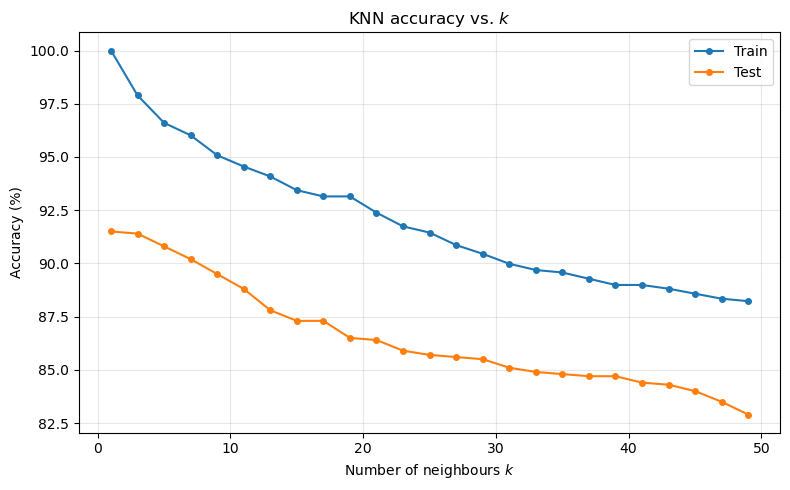

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(ks, train_accs, marker='o', markersize=4, label='Train')
plt.plot(ks, test_accs,  marker='o', markersize=4, label='Test')
plt.xlabel('Number of neighbours $k$')
plt.ylabel('Accuracy (%)')
plt.title('KNN accuracy vs. $k$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('knn_sweep.png', dpi=150)
plt.show()

In [14]:
# task 4
# using k=3 best performing 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


knn =KNeighborsClassifier(n_neighbors=3)
knn.fit(train_in,train_out)

knn_train_pred =knn.predict(train_in)
knn_test_pred =knn.predict(test_in)

print(f"KNN Train Acuuracy k=3 {accuracy_score(train_out,knn_train_pred):.2f}")
print(f"KNN test Acuuracy k=3 {accuracy_score(test_out,knn_test_pred):.2f}")

for group in range(10):
    # boolean mask
    mask = (test_out == group)
    group_predictions = knn_test_pred[mask]
    group_targets = test_out[mask]
    correct = np.sum(group_predictions == group_targets)
    total = len(group_targets)
    percentage = correct / total * 100
    print(f"digit{group}: {percentage:.1f}%({correct}/{total})")

KNN Train Acuuracy k=3 0.98
KNN test Acuuracy k=3 0.91
digit0: 97.8%(219/224)
digit1: 98.3%(119/121)
digit2: 86.1%(87/101)
digit3: 88.6%(70/79)
digit4: 90.7%(78/86)
digit5: 67.3%(37/55)
digit6: 95.6%(86/90)
digit7: 87.5%(56/64)
digit8: 85.9%(79/92)
digit9: 94.3%(83/88)


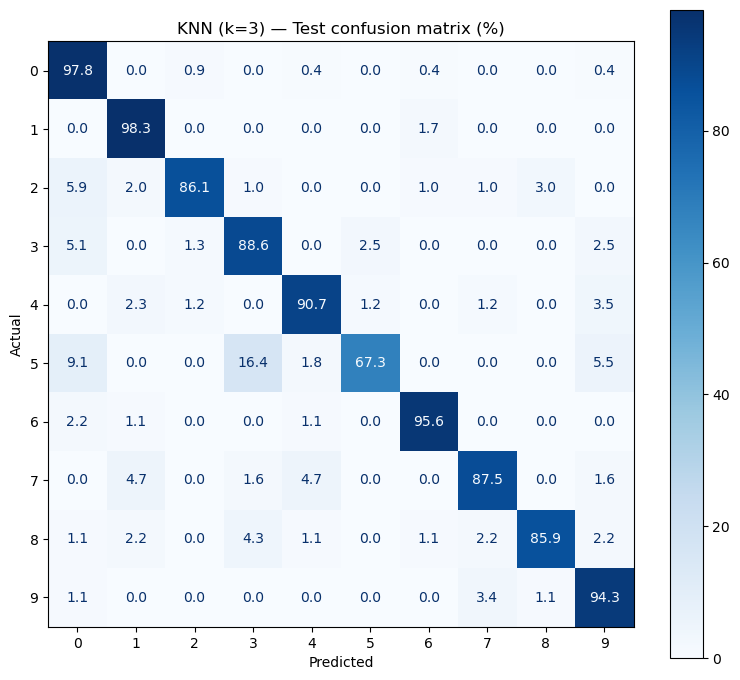

In [ ]:
# confusion matrix — KNN (test)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_knn = confusion_matrix(test_out, knn_test_pred, labels=range(10))
cm_knn_pct = cm_knn / cm_knn.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm_knn_pct, display_labels=range(10)).plot(
    ax=ax, cmap='Blues', values_format='.1f'
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('KNN (k=3) — Test confusion matrix (%)')
plt.tight_layout()
plt.show()

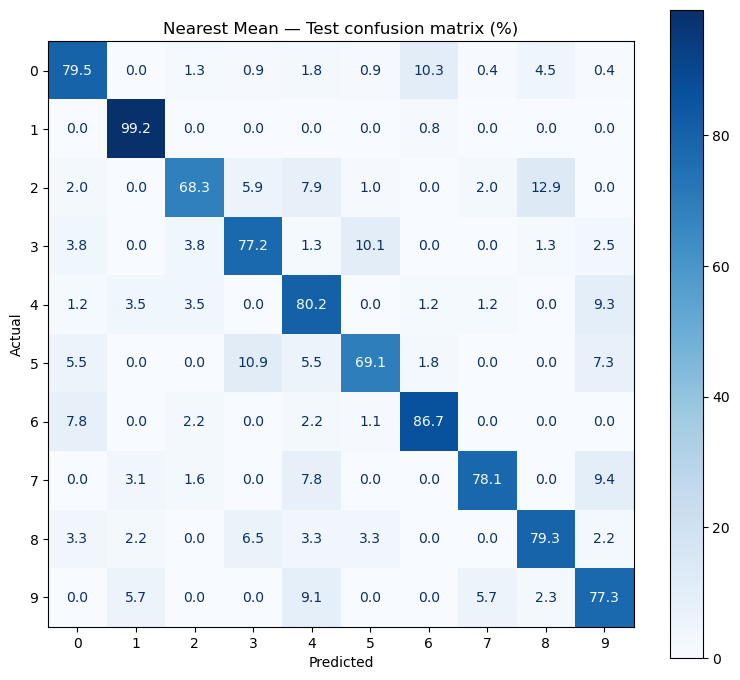

In [ ]:
# confusion matrix — nearest mean (test)
cm_nm = confusion_matrix(test_out, test_predictions, labels=range(10))
cm_nm_pct = cm_nm / cm_nm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm_nm_pct, display_labels=range(10)).plot(
    ax=ax, cmap='Blues', values_format='.1f'
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Nearest Mean — Test confusion matrix (%)')
plt.tight_layout()
plt.show()